In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df1 = pd.read_csv('coffee_analysis.csv')

In [3]:
roast = df1.groupby('roast')['rating'].mean().sort_values(ascending=False).reset_index()
display(roast)

,roast,rating
0,Light,93.522648
1,Medium-Light,93.226174
2,Medium,92.274131
3,Medium-Dark,91.871795
4,Dark,88.200000


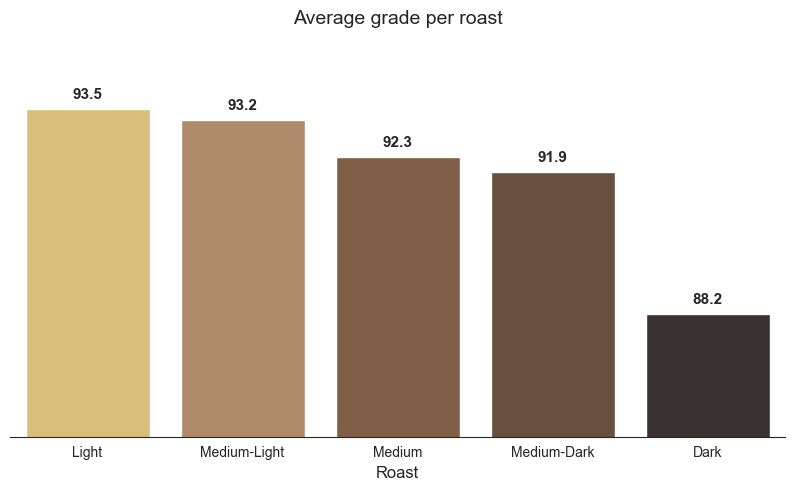

In [4]:
plt.figure(figsize=(10, 5))
sns.set_style("white") # Style très épuré sans grille

coffee_palette = {
    'Light': '#E9C46A',          # Doré / Blond
    'Medium-Light': '#BC8A5F',   # Cannelle / Brun clair
    'Medium': '#8B5E3C',         # Brun moyen
    'Medium-Dark': '#6F4E37',    # Café classique
    'Dark': '#3C2F2F'            # Chocolat noir / Brûlé
}

ax = sns.barplot(data=roast, x='roast', y='rating', palette=coffee_palette, hue='roast')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontsize=11, fontweight='bold')

plt.ylim(85,95)

plt.title('Average grade per roast', fontsize=14, pad=20)
plt.xlabel('Roast', fontsize=12)

ax.get_yaxis().set_visible(False) 
sns.despine(left=True) 

plt.show()

In [7]:
df1['review_date'] = pd.to_datetime(df1['review_date'], format='%B %Y')
df1['year_month'] = df1['review_date'].dt.to_period('M')
df1['year'] = df1['review_date'].dt.year

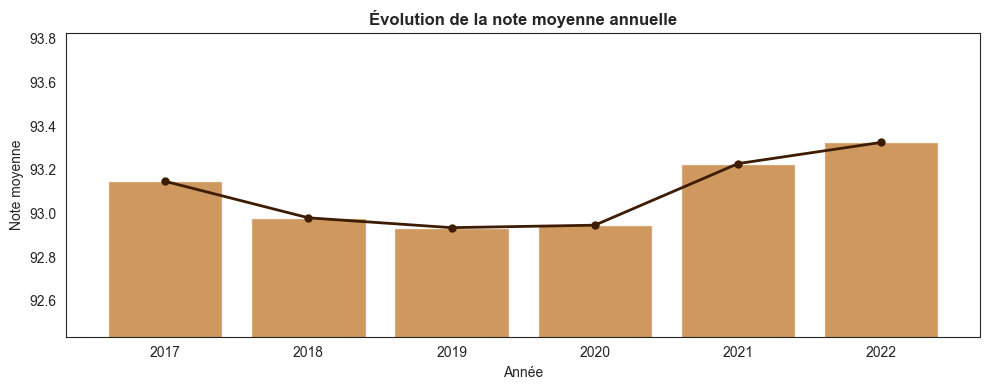

In [8]:
yearly = df1.groupby('year')['rating'].mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(yearly.index, yearly.values, color='#c68642', alpha=0.85, edgecolor='white')
ax.plot(yearly.index, yearly.values, color='#3d1c02', linewidth=2, marker='o', markersize=5)

ax.set_title('Évolution de la note moyenne annuelle', fontweight='bold')
ax.set_ylabel('Note moyenne')
ax.set_xlabel('Année')
ax.set_ylim(yearly.min() - 0.5, yearly.max() + 0.5)

plt.tight_layout()
plt.show()

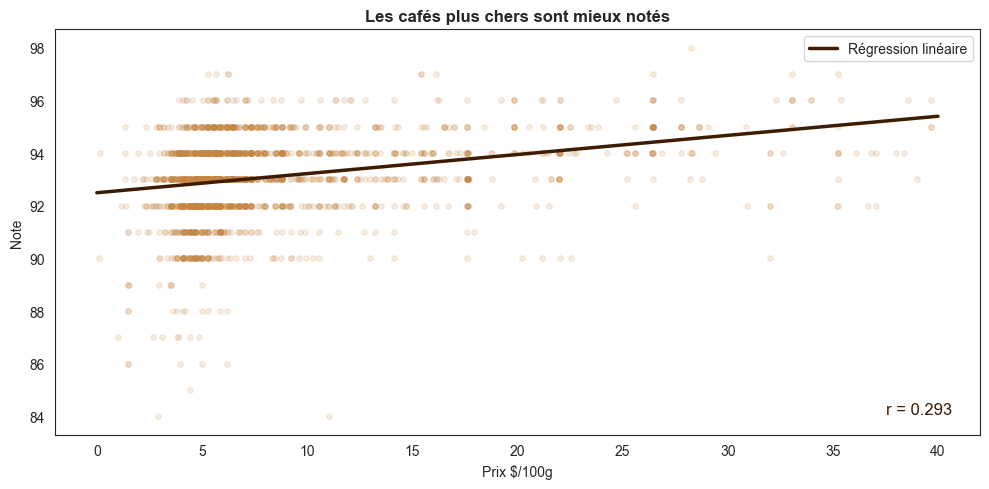

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

df_clip = df1[df1['100g_USD'] <= 40]

ax.scatter(df_clip['100g_USD'], df_clip['rating'], alpha=0.15, s=15, color='#c68642')

z = np.polyfit(df_clip['100g_USD'], df_clip['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 40, 100)
ax.plot(x_line, p(x_line), color='#3d1c02', linewidth=2.5, label='Régression linéaire')

corr = df_clip[['100g_USD', 'rating']].corr().iloc[0, 1]
ax.text(0.97, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=12, color='#3d1c02',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

ax.set_title('Les cafés plus chers sont mieux notés', fontweight='bold')
ax.set_xlabel('Prix $/100g')
ax.set_ylabel('Note')
ax.legend()

plt.tight_layout()
plt.show()

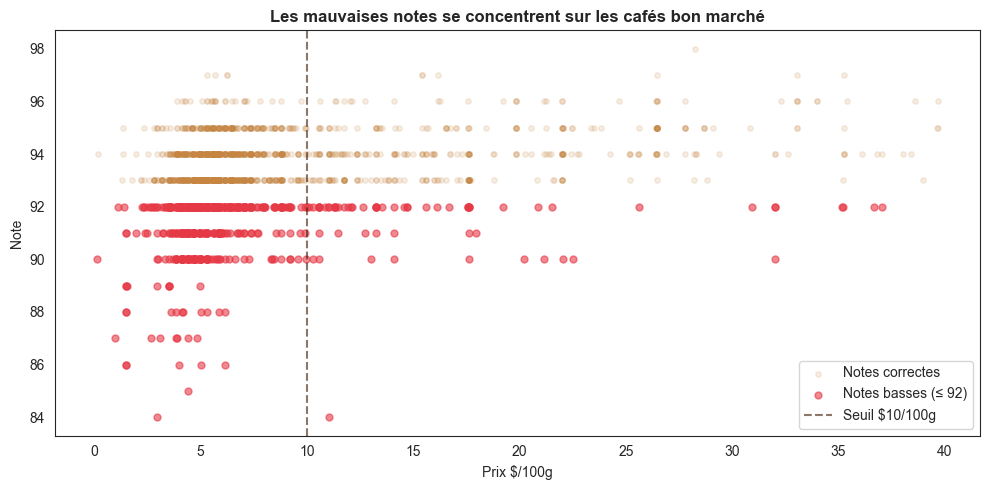

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

df_clip = df1[df1['100g_USD'] <= 40]

# Seuil bas de note
note_seuil = df_clip['rating'].quantile(0.15)

# Cafés mal notés vs bien notés
bad = df_clip[df_clip['rating'] <= note_seuil]
good = df_clip[df_clip['rating'] > note_seuil]

ax.scatter(good['100g_USD'], good['rating'], alpha=0.15, s=15, color='#c68642', label='Notes correctes')
ax.scatter(bad['100g_USD'], bad['rating'], alpha=0.6, s=25, color='#e63946', label=f'Notes basses (≤ {note_seuil:.0f})')

ax.axvline(x=10, color='#3d1c02', linestyle='--', linewidth=1.5, alpha=0.6, label='Seuil $10/100g')

ax.set_title('Les mauvaises notes se concentrent sur les cafés bon marché', fontweight='bold')
ax.set_xlabel('Prix $/100g')
ax.set_ylabel('Note')
ax.legend()

plt.tight_layout()
plt.show()

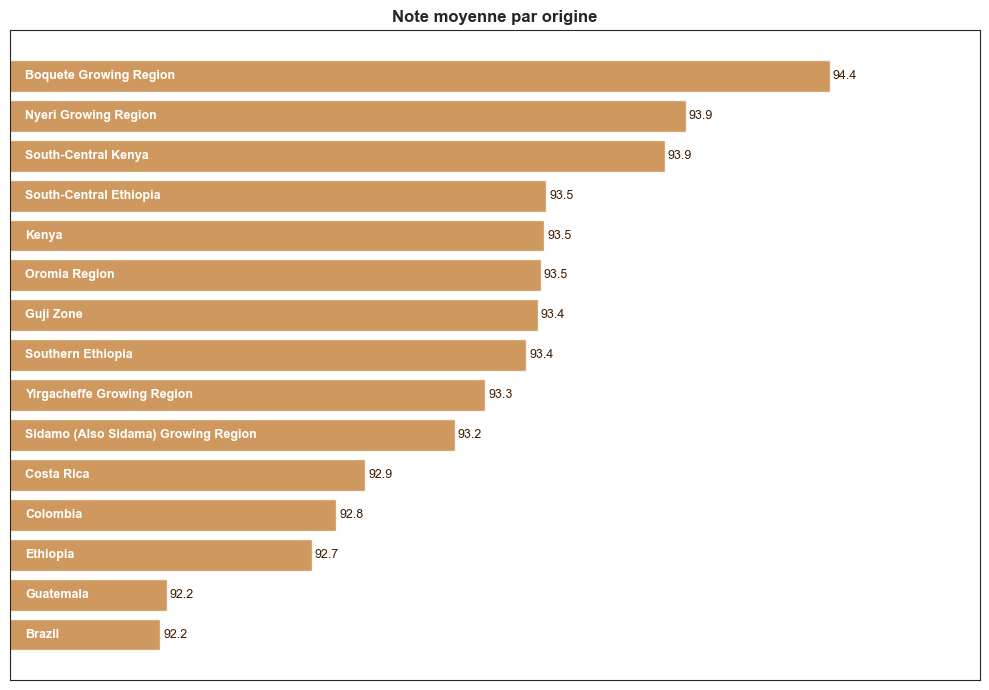

In [20]:
origins = pd.concat([
    df1[['origin_1', 'rating']].rename(columns={'origin_1': 'origin'}),
    df1[['origin_2', 'rating']].rename(columns={'origin_2': 'origin'})
]).dropna(subset=['origin'])

top_origins = origins['origin'].value_counts().head(15).index
df_orig = origins[origins['origin'].isin(top_origins)]

stats = df_orig.groupby('origin')['rating'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(stats.index, stats.values, color='#c68642', alpha=0.85, edgecolor='white')

for orig, val in stats.items():
    # Nom à l'intérieur
    ax.text(stats.min() - 0.45, orig, orig, va='center', ha='left', fontsize=9, color='white', fontweight='bold')
    # Note au bout
    ax.text(val + 0.01, orig, f'{val:.1f}', va='center', fontsize=9, color='#3d1c02')

ax.set_xlim(stats.min() - 0.5, stats.max() + 0.5)
ax.set_title("Note moyenne par origine", fontweight='bold')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.show()